# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score,StratifiedKFold, RandomizedSearchCV
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load the Dataset

In [2]:
url = "https://raw.githubusercontent.com/Bumb1eBee20/Portfolio/61172ba1c39dc86f2c15cb80257acf06a391a6a1/diabetes.csv"
df = pd.read_csv(url)

# Preview of the data

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# Initial Data Understanding

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Dataset Dimensions

In [5]:
# Shape of Dataset
print("Shape : ",df.shape)
# Size of Dataset
print("Size : ",df.size)

Shape :  (768, 9)
Size :  6912


## Check DataTypes

In [6]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


## Observation :

The dataset does not contain any explicit missing (NaN) values. However, several medically unrealistic values of 0 are present in columns such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI. These zero values are treated as missing values during preprocessing.

# Data Cleaning

## Checking Duplicate Records and Missing Values

In [7]:
print("No.of Duplicates : ",df.duplicated().sum())
print("="*50)
print("No.of Null Values : ")
print(df.isnull().sum())

No.of Duplicates :  0
No.of Null Values : 
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Observation :

The Dataset doesn't contain any missing values or duplicate records as of now.

# Descriptive Statistical Analysis

In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
print("Mode : ")
print(df.mode().iloc[0])

Mode : 
Pregnancies                  1.000
Glucose                     99.000
BloodPressure               70.000
SkinThickness                0.000
Insulin                      0.000
BMI                         32.000
DiabetesPedigreeFunction     0.254
Age                         22.000
Outcome                      0.000
Name: 0, dtype: float64


## Observation :

- The average Outcome is approximately 0.34, indicating that around 34% of the individuals in the dataset have diabetes.

- Outcome is a binary discrete variable containing only 0 and 1.

- Pregnancies ranges from 0 to 17, with an average of approximately 3.8 pregnancies.

- Glucose ranges from 0 to 199, with an average level of approximately 120.

- BloodPressure ranges from 0 to 122, with an average of approximately 69.

- SkinThickness ranges from 0 to 99, with an average of approximately 20.

- BMI ranges from 0 to 67, with an average of approximately 31.

- Some variables, including Glucose, BloodPressure, SkinThickness, Insulin, and BMI, contain values of 0, which may represent missing or invalid measurements.

- The descriptive statistics also suggest the presence of potential extreme values in variables such as Pregnancies, Insulin, and DiabetesPedigreeFunction. These will be further examined using boxplots.

# Exploratory Data Analysis

In [10]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [11]:
numerical_cols = df.drop(columns = "Outcome").columns
print("Numerical Columns :")
print(numerical_cols)

Numerical Columns :
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')


## Boxplot Analysis

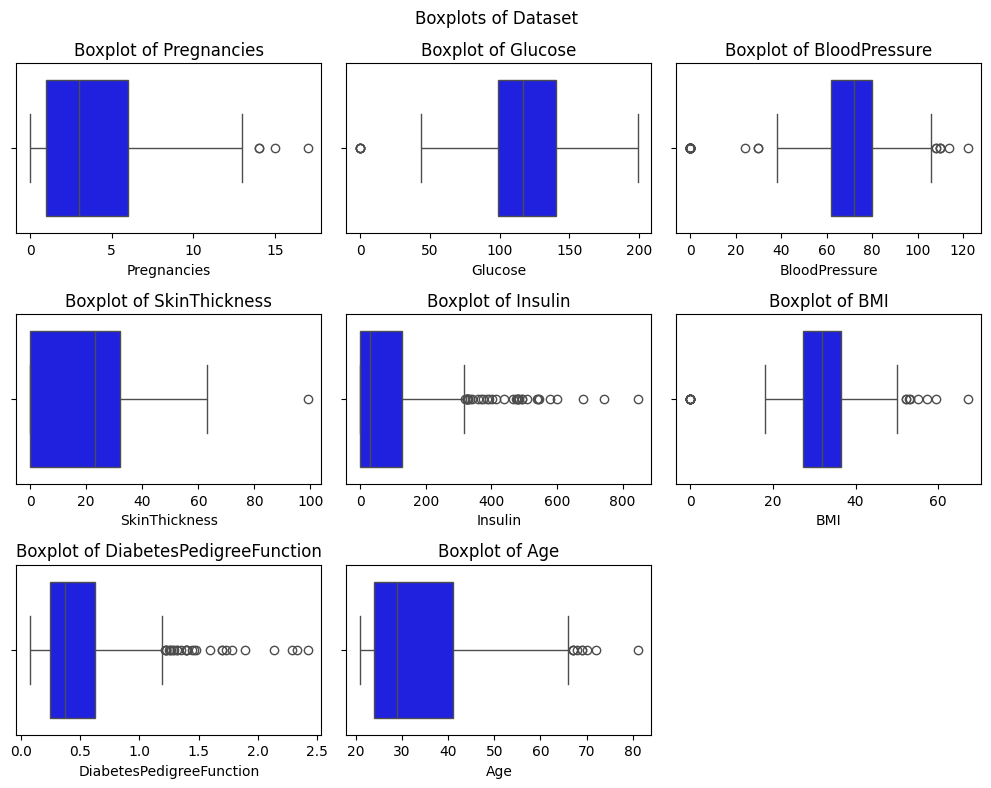

In [12]:
fig, ax = plt.subplots(3, 3, figsize=(10, 8))

for axis, col in zip(ax.flat, numerical_cols):
    sns.boxplot(data=df,x=col,ax=axis,color="blue")
    axis.set_title(f"Boxplot of {col}")

for axis in ax.flat[len(numerical_cols) :]:
    axis.remove()

plt.suptitle("Boxplots of Dataset")
plt.tight_layout()
plt.show()

### Observation :

- Insulin, DiabetesPedigreeFunction, and BMI show a relatively higher number of potential outliers compared with the other variables.
- Pregnancies, Glucose, BloodPressure, and SkinThickness show comparatively fewer potential outliers.

## Histogram Analysis

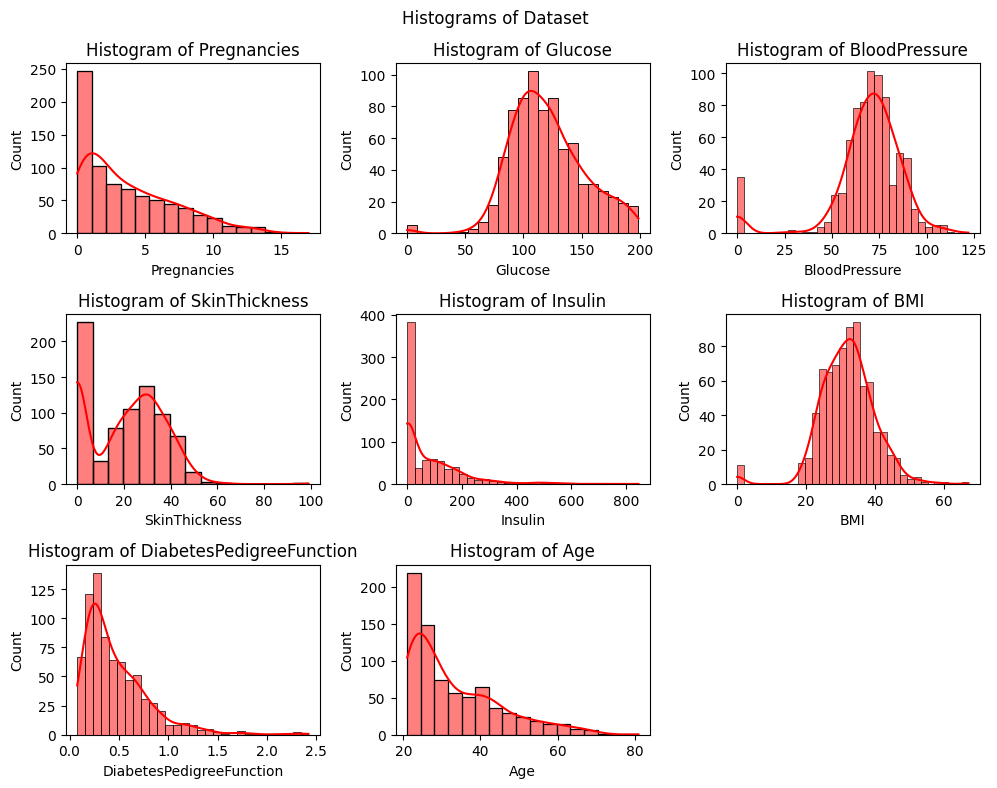

In [13]:
fig, ax = plt.subplots(3, 3, figsize=(10, 8))

for axis, col in zip(ax.flat, numerical_cols):
    sns.histplot(data=df,x=col,ax=axis,color="red",kde=True)
    axis.set_title(f"Histogram of {col}")

for axis in ax.flat[len(numerical_cols) :]:
    axis.remove()

plt.suptitle("Histograms of Dataset")
plt.tight_layout()
plt.show()

### Observation :

Pregnancies, Insulin, and Age appear to be right-skewed. The distributions of SkinThickness and BMI contain noticeable concentrations near zero, which may be influenced by invalid zero values representing missing data. Therefore, these distributions should be interpreted cautiously before preprocessing.

## Scatterplot Analysis

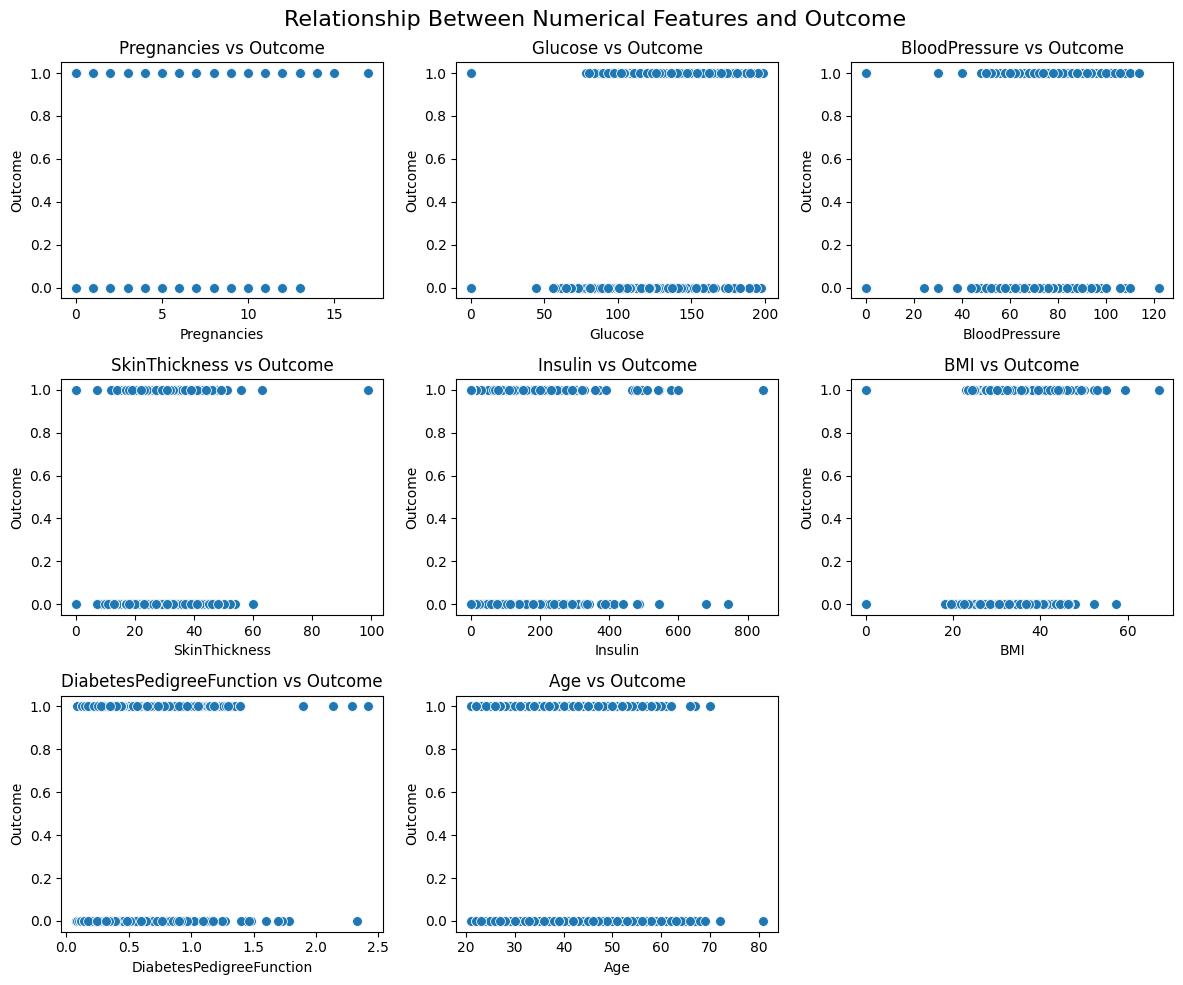

In [14]:
fig, ax = plt.subplots(3, 3, figsize=(12, 10))

for axis, col in zip(ax.flat, numerical_cols):

    sns.scatterplot(data=df, x=col, y="Outcome", ax=axis, s=50)

    axis.set_title(f"{col} vs Outcome")

# Remove empty subplots
for axis in ax.flat[len(numerical_cols):]:
    axis.remove()

plt.suptitle("Relationship Between Numerical Features and Outcome", fontsize=16)

plt.tight_layout()

plt.show()

### Observation :

Since Outcome is a binary variable containing only 0 and 1, the scatterplots show observations concentrated at two horizontal levels. This makes it difficult to identify strong relationships visually. However, variables such as Glucose, BMI, and Age show some separation between diabetic and non-diabetic groups.

## Countplot Analysis

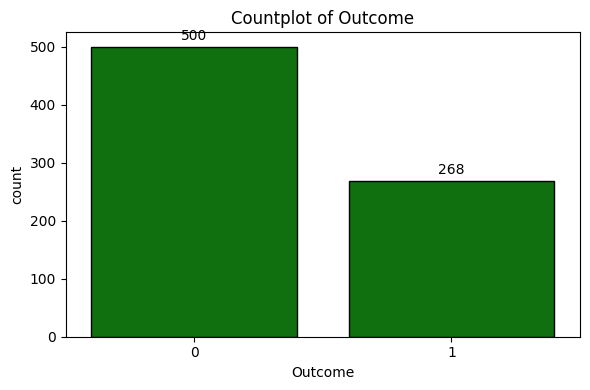

Outcome 0 : 65.10416666666666
Outcome 1 : 34.89583333333333


In [15]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df,x="Outcome",edgecolor="black",color="green")
plt.title("Countplot of Outcome")
plt.xlabel("Outcome")

for container in ax.containers:
  ax.bar_label(container,padding=3)

plt.tight_layout()
plt.show()

count_0 = (df["Outcome"]==0).sum()
count_1 = (df["Outcome"]==1).sum()

print("Outcome 0 :", (count_0/len(df))*100)
print("Outcome 1 :", (count_1/len(df))*100)


### Observation :

- Most records belong to Outcome = 0, indicating that those individuals do not have diabetes.
- Approximately 65% of the records belong to the non-diabetic class, while approximately 35% belong to the diabetic class.
- The dataset shows a moderate class imbalance, but both classes are sufficiently represented for classification modeling.

## Correlation Analysis

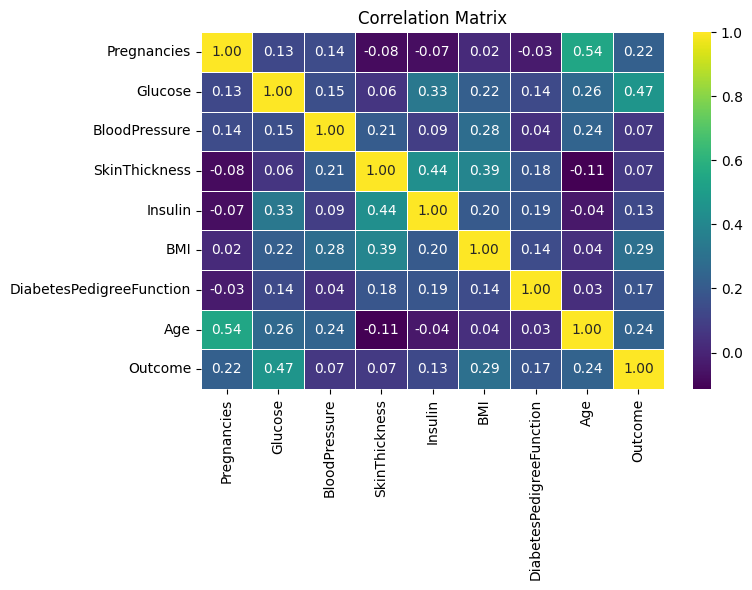

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,fmt=".2f",linewidths=0.5,cmap='viridis')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Observation :

- Pregnancies and Age show a positive correlation.
- Glucose has one of the strongest positive correlations with Outcome, indicating that higher glucose levels are associated with a higher likelihood of diabetes.
- BMI and Age also show positive relationships with Outcome.
- SkinThickness and Insulin show some correlation with other health-related variables.
- DiabetesPedigreeFunction has relatively low correlation with most variables; however, low correlation alone does not mean that the feature is unimportant. Its usefulness should be evaluated through model performance and feature analysis.

# Data Preprocessing

## Checking values of `0` in variables

In [17]:
print("No.of 0's in BMI :",(df["BMI"]==0).sum())
print("No.of 0's in Glucose :",(df["Glucose"]==0).sum())
print("No.of 0's in Blood Pressure :",(df["BloodPressure"]==0).sum())
print("No.of 0's in Insulin :",(df["Insulin"]==0).sum())
print("No.of 0's in Skin Thickness :",(df["SkinThickness"]==0).sum())

No.of 0's in BMI : 11
No.of 0's in Glucose : 5
No.of 0's in Blood Pressure : 35
No.of 0's in Insulin : 374
No.of 0's in Skin Thickness : 227


### Observation :

Values of 0 in BMI, Glucose, BloodPressure, SkinThickness, and Insulin are considered physiologically unrealistic or invalid for this dataset. Therefore, these values are treated as missing values before training the machine learning model, as retaining them could negatively affect model performance.

## Replacing values of `0` with `np.nan`

In [18]:
cols_with_zeroes = ["BMI","Glucose","BloodPressure","Insulin","SkinThickness"]
df[cols_with_zeroes] = df[cols_with_zeroes].replace(0,np.nan)

## Checking Missing Values and Percentages

In [19]:
print("No.of Null Values : ")
print(df.isnull().sum())

No.of Null Values : 
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [20]:
missing_value_percentage = (df.isnull().sum()/len(df))*100
print("Missing Value Percentage : ")
print(missing_value_percentage.sort_values(ascending=False))

Missing Value Percentage : 
Insulin                     48.697917
SkinThickness               29.557292
BloodPressure                4.557292
BMI                          1.432292
Glucose                      0.651042
Pregnancies                  0.000000
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                      0.000000
dtype: float64


### Observation :

- Insulin contains approximately 49% missing values, which is a substantial proportion.
- SkinThickness contains approximately 30% missing values.
- BloodPressure contains approximately 5% missing values.
- BMI and Glucose contain relatively small percentages of missing values.

Median imputation is applied after the train-test split to prevent data leakage.

## Feature and Target Separation

In [21]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

print("X Shape : ",X.shape)
print("y Shape : ",y.shape)

X Shape :  (768, 8)
y Shape :  (768,)


## Train-Test Split

In [22]:
X_train,X_test,y_train,y_test = train_test_split(
                                                  X,y,test_size = 0.20,
                                                  random_state = 42,
                                                  stratify =y)

print("X_train Shape : ",X_train.shape)
print("X_test Shape : ",X_test.shape)
print("y_train Shape : ",y_train.shape)
print("y_test Shape : ",y_test.shape)

X_train Shape :  (614, 8)
X_test Shape :  (154, 8)
y_train Shape :  (614,)
y_test Shape :  (154,)


## Handling Missing Values with Median Imputation

In [23]:
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

## Checking Missing Values after imputation

In [24]:
print("Missing values in X_train after imputation:")
print(pd.DataFrame(X_train_imputed, columns=X.columns).isnull().sum())

print("\nMissing values in X_test after imputation:")
print(pd.DataFrame(X_test_imputed, columns=X.columns).isnull().sum())

Missing values in X_train after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Missing values in X_test after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [25]:
X_train_processed = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_imputed,
    columns=X_test.columns,
    index=X_test.index
)

# LGBM

## Model Training

In [26]:
model_LGBM = LGBMClassifier(random_state=42)
model_LGBM.fit(X_train_processed,y_train)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002446 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 664
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

LGBMClassifier(random_state=42)

## Prediction

In [27]:
y_pred_LGBM = model_LGBM.predict(X_test_processed)

## Evaluation Metrics

In [28]:
accuracy_LGBM = accuracy_score(y_test,y_pred_LGBM)
precision_LGBM = precision_score(y_test,y_pred_LGBM)
recall_LGBM = recall_score(y_test,y_pred_LGBM)
f1_LGBM = f1_score(y_test,y_pred_LGBM)

LGBM_eval_summary = pd.DataFrame({"Accuracy":[accuracy_LGBM],"Precision":[precision_LGBM],
                                  "Recall":[recall_LGBM],"F1":[f1_LGBM]})
print(LGBM_eval_summary)

   Accuracy  Precision   Recall        F1
0   0.75974   0.666667  0.62963  0.647619


In [29]:
LGBM_report = classification_report(y_test,y_pred_LGBM)
print(LGBM_report)

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       100
           1       0.67      0.63      0.65        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



## Confusion Matrix

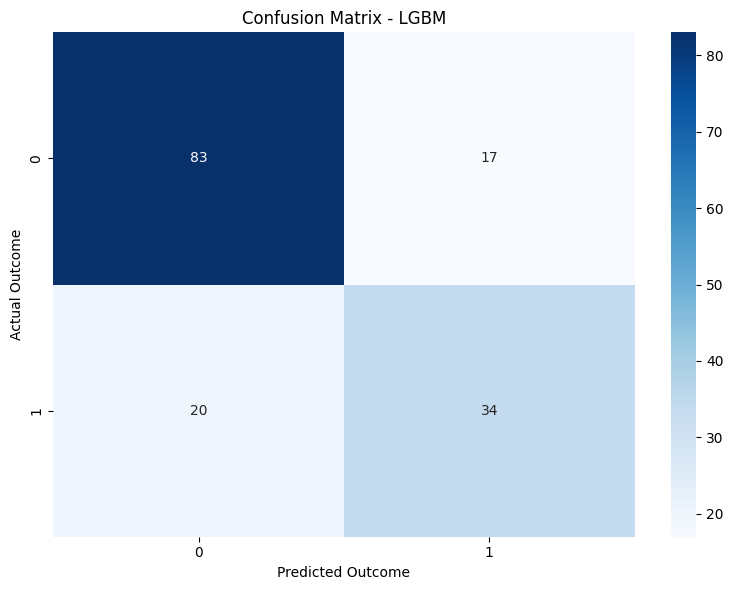

In [30]:
cm_LGBM = confusion_matrix(y_test,y_pred_LGBM)

plt.figure(figsize = (8,6))

sns.heatmap(cm_LGBM,annot = True,fmt="d",cmap="Blues",
            xticklabels = model_LGBM.classes_,
            yticklabels = model_LGBM.classes_)
plt.title("Confusion Matrix - LGBM")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.tight_layout()
plt.show()

## Observation :

- The LightGBM model achieved an accuracy of approximately 75%.
- The model achieved balanced precision and recall scores of approximately 65% for identifying diabetic cases.
- The F1-score of approximately 65% indicates moderate overall classification performance.
- The model correctly identifies a reasonable number of diabetic cases but still produces some false positives and false negatives.

# XGBOOST

## Model Training

In [31]:
model_XGB = XGBClassifier(random_state=42,eval_metric="logloss")
model_XGB.fit(X_train_processed,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## Prediction

In [32]:
y_pred_XGB = model_XGB.predict(X_test_processed)

## Evaluation Metrics

In [33]:
accuracy_XGB = accuracy_score(y_test,y_pred_XGB)
precision_XGB = precision_score(y_test,y_pred_XGB)
recall_XGB = recall_score(y_test,y_pred_XGB)
f1_XGB = f1_score(y_test,y_pred_XGB)

XGB_eval_summary = pd.DataFrame({"Accuracy":[accuracy_XGB],"Precision":[precision_XGB],
                                  "Recall":[recall_XGB],"F1":[f1_XGB]})
print(XGB_eval_summary)

   Accuracy  Precision    Recall    F1
0  0.766234   0.695652  0.592593  0.64


In [34]:
XGB_report = classification_report(y_test,y_pred_XGB)
print(XGB_report)

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.59      0.64        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



## Confusion Matrix

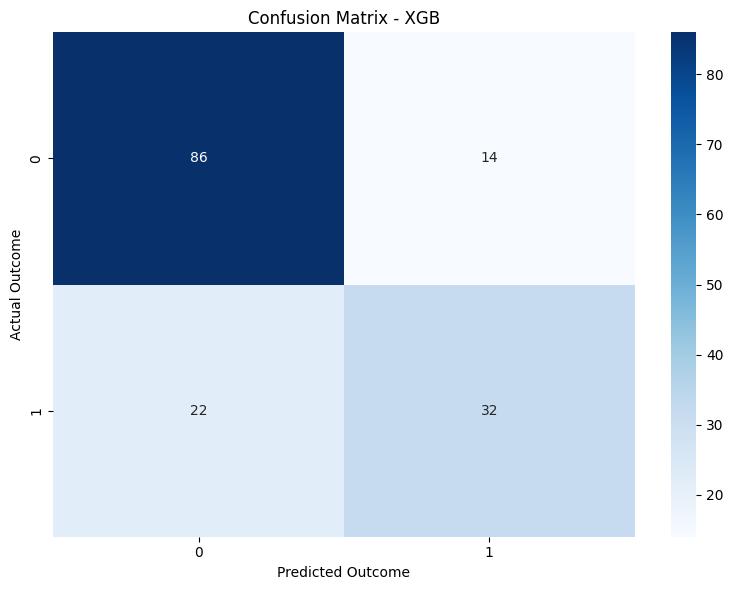

In [35]:
cm_XGB = confusion_matrix(y_test,y_pred_XGB)

plt.figure(figsize = (8,6))

sns.heatmap(cm_XGB,annot = True,fmt="d",cmap="Blues",
            xticklabels = model_XGB.classes_,
            yticklabels = model_XGB.classes_)
plt.title("Confusion Matrix - XGB")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.tight_layout()
plt.show()

## Observation :

- The XGBoost model achieved an accuracy of approximately 77%.
- It achieved higher precision than LightGBM, meaning its positive diabetes predictions were more reliable.
- However, its recall was lower, indicating that it missed more actual diabetic cases.
- The F1-score was approximately 64%, showing moderate classification performance.

# Comparing LGBM Vs XGBOOST

In [36]:
comparison_df = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost"],
    "Accuracy": [accuracy_LGBM, accuracy_XGB],
    "Precision": [precision_LGBM, precision_XGB],
    "Recall": [recall_LGBM, recall_XGB],
    "F1 Score": [f1_LGBM, f1_XGB]
})

print(comparison_df)

      Model  Accuracy  Precision    Recall  F1 Score
0  LightGBM  0.759740   0.666667  0.629630  0.647619
1   XGBoost  0.766234   0.695652  0.592593  0.640000


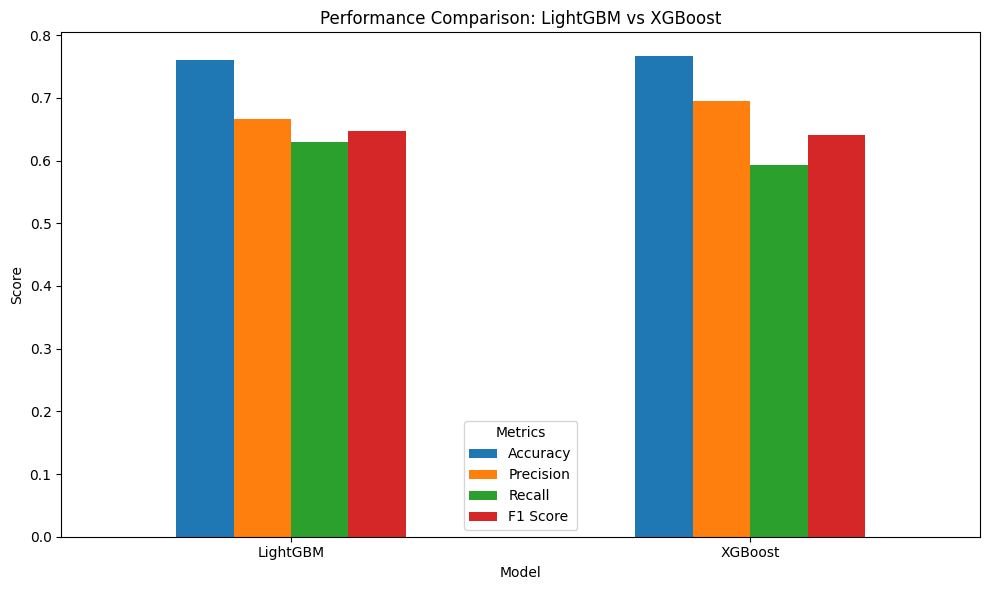

In [37]:
comparison_plot = comparison_df.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison: LightGBM vs XGBoost")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()

plt.show()

## Observation :

- XGBoost achieved slightly higher accuracy (76.62%) and precision (69.57%) compared to LightGBM.
- LightGBM achieved higher recall (62.96%) and a slightly higher F1-score (64.76%) than XGBoost.
- XGBoost produced fewer false positive predictions, while LightGBM detected more actual diabetic cases.
- Since recall is important in medical screening, LightGBM may be preferable when the goal is to reduce missed diabetes cases.
- Overall, both models demonstrated similar performance, with XGBoost performing slightly better in accuracy and precision, while LightGBM performed better in recall and F1-score.

# Cross-Validation

In [38]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

## LGBM Cross-Validation

In [39]:
LGBM_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),

    ("model", LGBMClassifier(
        random_state=42,
        verbosity=-1
    ))
])

In [40]:
LGBM_cv_scores = cross_val_score(LGBM_pipeline,X_train,y_train,
                                 cv=cv,scoring="accuracy",n_jobs=-1)
print("LightGBM Cross-Validation Scores : ")
print(LGBM_cv_scores)
print("="*50)
print("Mean CV Accuracy : ", LGBM_cv_scores.mean())
print("Standard Deviation : ", LGBM_cv_scores.std())

LightGBM Cross-Validation Scores : 
[0.76422764 0.7398374  0.77235772 0.68292683 0.75409836]
Mean CV Accuracy :  0.7426895908303346
Standard Deviation :  0.03179298180743873


## XGB Cross-Validation

In [41]:
XGB_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),

    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [42]:
XGB_cv_scores = cross_val_score(XGB_pipeline,X_train,y_train,
                                cv=cv,scoring = "accuracy",n_jobs=-1)

print("XGBoost Cross-Validation Scores : ")
print(XGB_cv_scores)
print("="*50)
print("Mean CV Accuracy:", XGB_cv_scores.mean())
print("Standard Deviation:", XGB_cv_scores.std())


XGBoost Cross-Validation Scores : 
[0.74796748 0.7398374  0.76422764 0.71544715 0.72131148]
Mean CV Accuracy: 0.7377582300413168
Standard Deviation: 0.01776210198199789


## Comparing Cross-Validation Results

In [43]:
cv_results = pd.DataFrame({
    "Model": ["LightGBM", "XGBoost"],
    "Mean CV Accuracy": [
        LGBM_cv_scores.mean(),
        XGB_cv_scores.mean()
    ],
    "Standard Deviation": [
        LGBM_cv_scores.std(),
        XGB_cv_scores.std()
    ]
})

cv_results

,Model,Mean CV Accuracy,Standard Deviation
0,LightGBM,0.742690,0.031793
1,XGBoost,0.737758,0.017762


### Observation:

- LightGBM achieved a slightly higher mean cross-validation accuracy of approximately 74.27%.
- XGBoost achieved a mean cross-validation accuracy of approximately 73.78%.
- XGBoost had a lower standard deviation, indicating more consistent performance across the five folds.
- Overall, both models demonstrated similar cross-validation performance, with LightGBM showing slightly higher average accuracy and XGBoost showing greater consistency.

# Hyperparameter Tuning

## Tuning LGBM

In [44]:
LGBM_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__num_leaves": [15, 31, 50, 70],
    "model__max_depth": [-1, 3, 5, 7, 10],
    "model__min_child_samples": [10, 20, 30, 40],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0]
}

LGBM_random = RandomizedSearchCV(
    estimator=LGBM_pipeline,
    param_distributions=LGBM_params,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

LGBM_random.fit(X_train, y_train)

print("Best Parameters:")
print(LGBM_random.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(LGBM_random.best_score_)

Best Parameters:
{'model__subsample': 0.8, 'model__num_leaves': 15, 'model__n_estimators': 300, 'model__min_child_samples': 40, 'model__max_depth': -1, 'model__learning_rate': 0.01, 'model__colsample_bytree': 1.0}

Best Cross-Validation F1 Score:
0.6415263795166569


## Tuning XGBoost

In [45]:
XGB_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.2, 0.3]
}


XGB_random = RandomizedSearchCV(
    estimator=XGB_pipeline,
    param_distributions=XGB_params,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

XGB_random.fit(X_train, y_train)

print("Best Parameters:")
print(XGB_random.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(XGB_random.best_score_)

Best Parameters:
{'model__subsample': 0.6, 'model__n_estimators': 100, 'model__min_child_weight': 7, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__gamma': 0.2, 'model__colsample_bytree': 0.8}

Best Cross-Validation F1 Score:
0.6626980127267559


## Interpretation

- XGBoost achieved a higher cross-validation F1-score of approximately 66.27% compared to LightGBM's 64.15%.
- This indicates that the tuned XGBoost model performed slightly better during cross-validation.
- However, the final model selection should also consider performance on the unseen test dataset.

## Evaluation of Tuned LGBM

In [46]:
# Get the best tuned LightGBM model
best_LGBM = LGBM_random.best_estimator_

# Predictions
LGBM_tuned_pred = best_LGBM.predict(X_test)

# Evaluation metrics
accuracy_LGBM_tuned = accuracy_score(y_test, LGBM_tuned_pred)
precision_LGBM_tuned = precision_score(y_test, LGBM_tuned_pred)
recall_LGBM_tuned = recall_score(y_test, LGBM_tuned_pred)
f1_LGBM_tuned = f1_score(y_test, LGBM_tuned_pred)

print("Tuned LightGBM Performance")
print("=" * 40)

print(f"Accuracy  : {accuracy_LGBM_tuned:.4f}")
print(f"Precision : {precision_LGBM_tuned:.4f}")
print(f"Recall    : {recall_LGBM_tuned:.4f}")
print(f"F1 Score  : {f1_LGBM_tuned:.4f}")

Tuned LightGBM Performance
Accuracy  : 0.7662
Precision : 0.6957
Recall    : 0.5926
F1 Score  : 0.6400


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Evaluation of Tuned XGBoost

In [47]:
# Get the best tuned XGBoost model
best_XGB = XGB_random.best_estimator_

# Predictions
XGB_tuned_pred = best_XGB.predict(X_test)

# Evaluation metrics
accuracy_XGB_tuned = accuracy_score(y_test, XGB_tuned_pred)
precision_XGB_tuned = precision_score(y_test, XGB_tuned_pred)
recall_XGB_tuned = recall_score(y_test, XGB_tuned_pred)
f1_XGB_tuned = f1_score(y_test, XGB_tuned_pred)

print("Tuned XGBoost Performance")
print("=" * 40)

print(f"Accuracy  : {accuracy_XGB_tuned:.4f}")
print(f"Precision : {precision_XGB_tuned:.4f}")
print(f"Recall    : {recall_XGB_tuned:.4f}")
print(f"F1 Score  : {f1_XGB_tuned:.4f}")

Tuned XGBoost Performance
Accuracy  : 0.7273
Precision : 0.6200
Recall    : 0.5741
F1 Score  : 0.5962


# Comparing All Models

In [48]:
final_results = pd.DataFrame({
    "Model": [
        "Baseline LightGBM",
        "Tuned LightGBM",
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],

    "Accuracy": [
        accuracy_LGBM,
        accuracy_LGBM_tuned,
        accuracy_XGB,
        accuracy_XGB_tuned
    ],

    "Precision": [
        precision_LGBM,
        precision_LGBM_tuned,
        precision_XGB,
        precision_XGB_tuned
    ],

    "Recall": [
        recall_LGBM,
        recall_LGBM_tuned,
        recall_XGB,
        recall_XGB_tuned
    ],

    "F1 Score": [
        f1_LGBM,
        f1_LGBM_tuned,
        f1_XGB,
        f1_XGB_tuned
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline LightGBM,0.759740,0.666667,0.629630,0.647619
1,Tuned LightGBM,0.766234,0.695652,0.592593,0.640000
2,Baseline XGBoost,0.766234,0.695652,0.592593,0.640000
3,Tuned XGBoost,0.727273,0.620000,0.574074,0.596154


# Final Observation

- Baseline LightGBM achieved the highest Recall (62.96%) and F1-score (64.76%), demonstrating the best balance between precision and recall.
- Tuned LightGBM achieved the highest Accuracy (76.62%) and Precision (69.57%), but its Recall and F1-score were slightly lower.
- Baseline XGBoost produced the same test-set performance metrics as Tuned LightGBM.
- Tuned XGBoost achieved the lowest performance among the evaluated models, despite obtaining the highest cross-validation F1-score during hyperparameter tuning.
- This demonstrates that better cross-validation performance does not always guarantee better performance on an unseen test set.
- Overall, Baseline LightGBM was selected as the best-performing model because it achieved the highest F1-score and Recall, providing a better balance for diabetes prediction.

# Feature Importance

## LGBM Feature Importance

In [49]:
# Get feature importance from LightGBM

LGBM_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_LGBM.feature_importances_
})

# Sort values
LGBM_importance = LGBM_importance.sort_values(
    by="Importance",
    ascending=False
)

LGBM_importance

,Feature,Importance
6,DiabetesPedigreeFunction,491
1,Glucose,408
5,BMI,389
7,Age,336
2,BloodPressure,284
0,Pregnancies,193
3,SkinThickness,183
4,Insulin,160


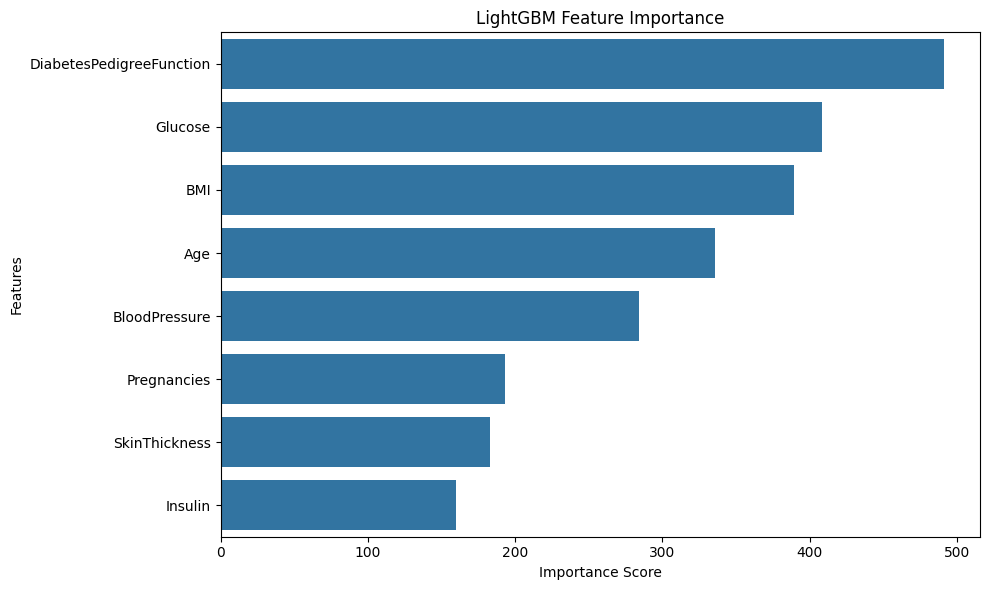

In [50]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=LGBM_importance,
    x="Importance",
    y="Feature"
)

plt.title("LightGBM Feature Importance")

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()

plt.show()

## XGB Feature Importance

In [51]:
# Get feature importance from XGBoost

XGB_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_XGB.feature_importances_
})

# Sort values
XGB_importance = XGB_importance.sort_values(
    by="Importance",
    ascending=False
)

XGB_importance

,Feature,Importance
1,Glucose,0.253679
5,BMI,0.147327
7,Age,0.126237
4,Insulin,0.120967
0,Pregnancies,0.102839
6,DiabetesPedigreeFunction,0.091122
2,BloodPressure,0.082134
3,SkinThickness,0.075694


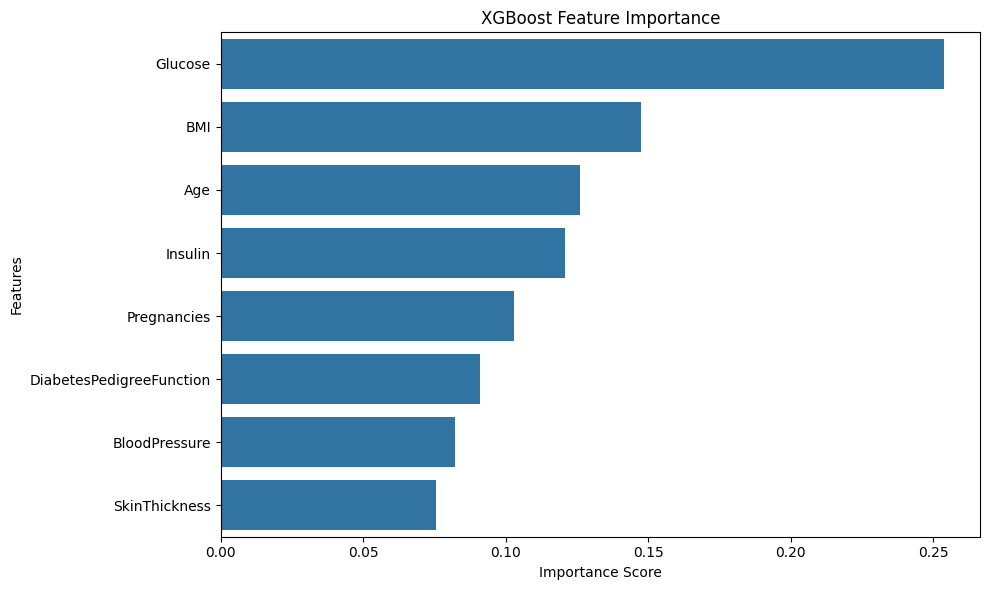

In [52]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=XGB_importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()

plt.show()

## Feature Importance Observation

### LightGBM

- DiabetesPedigreeFunction was the most important feature, followed by Glucose and BMI.
- Age and BloodPressure also showed considerable importance in the model.
- Insulin had the lowest importance among the features.
- LightGBM distributed importance relatively across multiple features, with DiabetesPedigreeFunction receiving the highest importance score.

### XGBoost

- Glucose was the most important feature by a substantial margin.
- BMI and Age were the next most important features.
- Insulin and Pregnancies showed moderate importance.
- SkinThickness had the lowest importance in the XGBoost model.

### Comparative Analysis

- Both models identified Glucose, BMI, and Age as important features for diabetes prediction.
- However, LightGBM identified DiabetesPedigreeFunction as the most influential feature, whereas XGBoost identified Glucose as the dominant feature.
- The difference in feature importance rankings shows that LightGBM and XGBoost learn different decision patterns from the same dataset.

# Conclusion

The objective of this project was to compare the performance of LightGBM and XGBoost algorithms for predicting diabetes using the given dataset.

During preprocessing, zero values in features such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI were treated as missing values and replaced using median imputation. The dataset was then divided into training and testing sets to evaluate the models on unseen data.

Both LightGBM and XGBoost demonstrated similar baseline performance during cross-validation, achieving approximately 74% mean accuracy. Hyperparameter tuning was performed using RandomizedSearchCV with F1-score as the optimization metric.

The final test-set evaluation showed that Tuned LightGBM and Baseline XGBoost achieved the highest accuracy and precision of approximately 76.62% and 69.57%, respectively. However, Baseline LightGBM achieved the highest recall of 62.96% and the highest F1-score of 64.76%.

Tuned XGBoost achieved the best cross-validation F1-score during hyperparameter tuning but performed worse on the unseen test set. This demonstrates that better cross-validation performance does not always guarantee better generalization on a specific test set.

Based on the overall evaluation, Baseline LightGBM was selected as the preferred model because it achieved the highest F1-score and recall, providing a better balance between correctly identifying diabetic cases and avoiding incorrect predictions.

Feature importance analysis showed that Glucose, BMI, Age, and DiabetesPedigreeFunction were influential features for diabetes prediction. The two models assigned different importance rankings to some features, demonstrating differences in how LightGBM and XGBoost learn patterns from the data.

Overall, both algorithms demonstrated competitive performance, with LightGBM providing the best balance of Recall and F1-score, while XGBoost demonstrated stronger Accuracy and Precision.